# CS541: Applied Machine Learning, Spring 2026, Problem Set 3
### _Note: Do not delete or add blocks, do not change the function names. If you do this the autograder won't run properly and you might get a 0. Avoid using global variables inside your function. Failing to define your variables correctly could result in a score of 0._

Problem set 3 is due in Gradescope on **Mar 31 at 11:59pm**.
All the questions are in this jupyter notebook file. There are four questions in this assignment, each of which could have multiple parts and consists of a mix of coding and short answer questions. This assignment is worth a total of **112 points** (**53 pts** coding, and **59 pts** short answer).  Note that each individual pset contributes the same amount to the final grade regardless of the number of points it is worth.

After completing these questions you will need to covert this notebook into a .py file named **ps3.py** and a pdf file named **ps3.pdf** in order to submit it (details below).

**Submission instructions:** please upload your completed solution files to Gradescope by the due date. **Make sure you have run all code cells and rendered all markdown/Latex without any errors.**

There will be two separate submission links for the assignment:
1. Submit **ps3.py** to `PS3-Code`
2. Submit a single `.pdf` report that contains your work for all written questions to `PS3`. You can type your responses in LaTeX, or any other word processing software.  You can also hand write them on a tablet, or scan in hand-written answers. If you hand-write, please make sure they are neat and legible. If you are scanning, make sure that the scans are legible. Lastly, convert your work into a `PDF`. You can use Jupyter Notebook to convert the formats:
  + Convert to PDF file: Go to File->Download as->PDF
  + Convert py file: Go to File->Download as->py\
You can take a look at an example [here](https://raw.githubusercontent.com/chaudatascience/cs599_fall2022/master/ps1/convert_py.gif)

  Your written responses in the PDF report should be self-contained. It should include all the output you want us to look at. You will not receive credit for any results you have obtained, but failed to include directly in the PDF report file.  Please tag the reponses in your PDF with the Gradescope questions outline as described in [Submitting an Assignment](https://youtu.be/u-pK4GzpId0). **Please do mark the pages against each question when you make your PDF submission.**

**Assignment Setup**

You are strongly encouraged to use [Google Colab](https://colab.research.google.com/) for this assignment.

If you would prefer to setup your code locally on your own machine, you will need [Jupyter Notebook](https://jupyter.org/install#jupyter-notebook) or [JupyterLab](https://jupyter.org/install#jupyterlab) installation. One way to set it up is to install “Anaconda” distribution, which has Python (you should install python version >= 3.9 as this notebook is tested with python 3.9), several libraries including the Jupyter Notebook that we will use in class. It is available for Windows, Linux, and Mac OS X [here](https://docs.conda.io/en/latest/miniconda.html).

If you are not familiar with Jupyter Notebook, you can follow [this blog](https://realpython.com/jupyter-notebook-introduction/) for an introduction.  After developing your code using Jupyter, you are encouraged to test it on Google Colab to ensure it works in both settings.


You cannot use packages other than the ones already imported in this assignment.


**Jupyter Tip 1**: To run a cell, press `Shift+Enter` or click on "play" button above. To edit any code or text cell [double] click on its content. To change cell type, choose "Markdown" or "Code" in the drop-down menu above.


**Jupyter Tip 2**: Use shortcut "Shift + Tab" to show the documentation of a function in Jupyter Notebook/ Jupterlab. Press Shift then double Tab (i.e., press Tab twice) to show the full documentation.\
For example, type `sum(` then Shift + Tab to show the documentation for the function, as shown in this the picture below.

In [ ]:
## import some libraries
import sklearn
from sklearn import datasets
import numpy as np
from typing import Tuple, List, Dict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import cdist
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from tqdm import tqdm

# **Question 1.** Linear Regression (*15 total points*)

## **1.1 Code:** Linear Regression using Sklearn *(5 pts)*

In this section, we will work with a demo dataset. The data consists of 2 columns: `hours_practice` (number of hours to practice) and `score`.

In [ ]:
## Read the dataset
df = pd.read_csv("https://raw.githubusercontent.com/chaudatascience/cs599_fall2022/master/ps3/linear_data.csv")
print("data shape:", df.shape)
df.sample(4)

In [ ]:
## Extract features and labels as numpy arrays
X = df.values[:,0:1]  # features
y = df.values[:,1]  # labels

In [ ]:
## Plot the dataset
sns.scatterplot(data=df, x="hours_practice", y="score")

In this section, we will train a Linear Regression model on the dataset using Sklearn.
You can refer to the document on Linear Regression [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

In [ ]:
from sklearn.linear_model import LinearRegression

def question_1_1(X: np.ndarray, y: np.ndarray) -> LinearRegression:
    """
    Train a Sklearn's Linear Regression model on features `X` and labels `y`.
    X: 2d numpy array, shape of (num_samples, feat_dim)
    y: numpy array, shape of (num_samples, )
    return a trained Linear Regression model

    """
    # Write your code in this block -----------------------------------------------------------



    # End of your code -----------------------------------------------------------

    return model


In [ ]:
## Test your model
def plot_model(linear_model, X, y, start, end):
    print("Model slope:    ", linear_model.coef_)
    print("Model intercept:", linear_model.intercept_)

    xfit = np.linspace(start, end, 500)[:, np.newaxis]
    if len(linear_model.coef_) == 2:
        xfit = np.concatenate([xfit, xfit**2], axis=1)
    yfit = linear_model.predict(xfit)

    plt.figure(figsize=(10,5))
    plt.scatter(X[:,0], y, s=5)
    plt.xlabel("hours_practice")
    plt.ylabel("score")
    plt.plot(xfit[:,0], yfit, 'r+')

# Get your model
linear_model = question_1_1(X, y)

# Plot: Your regression line is the red line as shown below
start, end = 20, 80  # start and end of the line
plot_model(linear_model, X, y, start, end)

## **1.2 Code:** Polynomial features *(5 pts)*

Let's take a look at another demo dataset

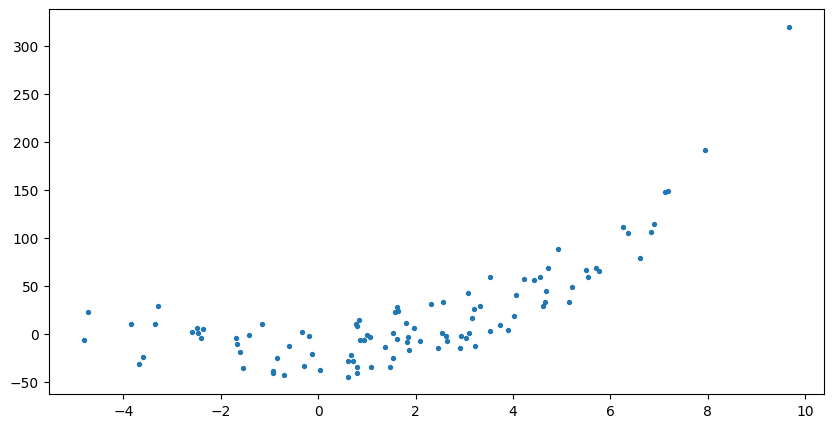

In [9]:
data = pd.read_csv("https://raw.githubusercontent.com/chaudatascience/cs599_fall2022/master/ps3/polynomial.csv").values
X2, y2 = data[:,:1], data[:,1]
plt.figure(figsize=(10,5))
plt.scatter(X2, y2, s=8)

We can see that the dataset is not linear. In other words, using a line can not capture the pattern in the data, resulting in underfitting. To solve this, we need to make our model a bit more complex.

There is a trick we can use to capture nonlinear relationships between variables: We first transform existing feature by some basic function, then use the generated data as new feature.

For example, with a linear regression for 1-d feature $x$:

$$Y=\theta_0+\theta_1 x$$

We can transform the input feature $x$ to get a new feature, such as $x$ squared and consider it as a new feature.
We now have 2 features, and the model becomes polynomial regression:

$$Y=\theta_0+\theta_1 x+\theta_2 x^2$$

We can keep adding: $$Y=\theta_0+\theta_1 x+\theta_2 x^2+ \theta_3 x^3 + ....$$ to get even more complex model.

You will need to write a function to concatenate $X^2$ as a feature alongside X. So, now, the training data `X_new` will have X and $X^2$ as the features

In [ ]:
def question_1_2(X: np.ndarray) -> np.ndarray:
    """
        Given numpy array X, shape of (num_sample, 1).
        Return a numpy array, shape of (num_sample, 2) by adding a new column to the right of X.
        The new column is the square of the existing column in X
    """
    # Write your code in this block -----------------------------------------------------------

    return X_new


    # End of your code -----------------------------------------------------------


## Test your function
X_new = question_1_2(X2)
print("X_new.shape", X_new.shape)
print(X_new[:5]) # show the first 5 samples

In [ ]:
## Plot the new model (in red)
new_linear_model = question_1_1(X_new, y2)
plot_model(new_linear_model, X_new, y2, start=-5, end=12)

We can see the curve fits the data much better than a straight line.

## **1.3 Short answer:**  Linear model *(5 pts)*
**Question:**
    What is the shape of the curve (linear, or non-linear?)
    Is the model still considered to be a linear model?

Write your answer in this block

**Your Answer:**


# Question 2. Linear Regression with Regularization *(22 total points*)

With basis functions, our model become more flexible, but it comes with a cost: The model is easier to over-fitting. One way to reduce overfitting is to penalize higher degree polynomials. This ensures that we only use the higher degree polynomials if the error is significantly reduced compared to a simpler model.

In this section, we will work on Boston Housing dataset. This dataset was taken from the [StatLib library](http://lib.stat.cmu.edu/datasets/) which is maintained at Carnegie Mellon University. It consists of 13 continous features and a numerical target named *MEDV*. For more details about the dataset, you can refer [this link](https://raw.githubusercontent.com/chaudatascience/cs599_fall2022/master/ps3/boston_housing_name.txt).

Our goal is to train a linear regression model with regularization to learn the relationship between suburb characteristics and house prices.


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/chaudatascience/cs599_fall2022/master/ps3/boston_housing.csv")
print("df.shape", df.shape)
df.sample(5)

In [ ]:
## Extract features and labels as numpy arrays
X, y = df.iloc[:, :-1], df.iloc[:, -1]

## Split to train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

## Check on the shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Sklearn provides a useful module named [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) which comes in handy when we need to perform sequence of different transformations.

An Example of using Pipeline is shown as below. We want to normalize the data, then create some new polynomial
features, and finally a Linear model. Sklearn provides us
[PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) for generating polynomial and interaction features.

In [ ]:
##
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

## Steps is a list of Tuple[step_name, transformation_object]
steps = [
    ('scalar', StandardScaler()),   ## normilaze data
    ('poly', PolynomialFeatures(degree=2)),  ## add new features up to 2 degrees
    ('model', LinearRegression()) ## Linear regression model
]

linear_pipe = Pipeline(steps)
linear_pipe.fit(X_train, y_train)

## Let's see how we perform on the training and test sets
print('Training score: {}'.format(linear_pipe.score(X_train, y_train)))
print('Test score: {}'.format(linear_pipe.score(X_test, y_test)))

On training set, the model performs very well, but the score drops significantly on test set.
This suggests that our model is overfitting.

Now regularization comes for the rescue.

Recall that there are three main techniques for regularization in linear regression, where we add a regularization term to the loss:

+   Lasso Regression (L1 regularization):   $\alpha \sum_{j=1}^n\left|\theta_j\right|$
+   Ridge Regression (L2 regularization):   $\alpha \sum_{j=1}^n\left|\theta^2_j\right|$
+   Elastic Net (Combine L1 and L2 regularizations):     $\alpha_1 \sum_{j=1}^n\left|\theta_j\right| + \alpha_2 \sum_{j=1}^n\left|\theta^2_j\right|$

Where $n$ is the number of features, $\alpha$ is regularization parameter, which controls the degree of regularization.

In Sklearn, we can use `sklearn.linear_model.Lasso` for Linear Regression with L1 regularization. It also provides `sklearn.linear_model.Ridge` and `sklearn.linear_model.ElasticNet` for the other 2.

Similar to what we have done above, you should be able to perform a Linear Regresison with regularization.

Complete the function below for Lasso and Ridge regression by using the code example above. In the function, you should define **`steps` the same as we use in the example:** First, a "scalar", then "poly" followed by a "model". The only thing different here is the model (`Lasso` and `Ridge`, instead of `LinearRegression`)

## **2.1 Code:** Lasso and Ridge *(8 pts)*

In [ ]:
from sklearn.linear_model import Ridge, Lasso

def question_2_1(regularization: str, alpha_1: float, alpha_2: float,
                X_train, y_train, X_test, y_test) -> Tuple[float, float]:
    """
        regularization: one of ["L1", "L2"]. If "L1", use Lasso, otherwise use Ridge.
        alpha_1: regularization for Lasso (if Lasso is used)
        alpha_2: regularization for Ridge (if Ridge is used)
        X_train, y_train, X_test, y_test: numpy arrays, shapes (354, 13), (354,), (152, 13), (152,) respectively
        return a Tuple: (train_score, test_score) in that order,
        Note that train_score and test_score are float numbers in range [0,1]
    """
    # Write your code in this block -----------------------------------------------------------
    # You should define `steps` the same as we use in the example above:
    #       first a "scalar", then "poly" followed by a "model".


    ## Don't forget to return train and test scores!
    return train_score, test_score


    # End of your code -----------------------------------------------------------

In [ ]:
## Test your model
alpha_1 = 0.1
alpha_2 = 12
for regularization in ["L1", "L2"]:
    train_score, test_score = question_2_1(regularization, alpha_1, alpha_2,
                                                         X_train, y_train, X_test, y_test)
    print(f"regularization: {regularization}, train_score: {train_score}, test_score: {test_score}")



## **2.2 Short answer:** Regularization Effects *(7 pts)*

In [ ]:
alpha = 3
lasso = Lasso(alpha).fit(X_train, y_train)
ridge = Ridge(alpha).fit(X_train, y_train)

# Here the input feature dimension is 13 (we are using X_train and not the degree 2 polynomial features.)
# Recall that regularization will affect the coeffiecient placed on the features while making the prediction.
# Let's see how the coefficients look like with Lasso and Ridge.

coefficients = pd.DataFrame({"feature": list(range(len(lasso.coef_))), "value (Lasso)": lasso.coef_, "value (Ridge)": ridge.coef_})

## coefficients of Lasso
ax = sns.barplot(data=coefficients, x="feature", y="value (Lasso)")
ax.set( ylim=(-4, 4)) ## set  min, max for the y-axis
print("coefficients of Lasso")
plt.show()

## coefficients of Ridge
ax = sns.barplot(data=coefficients, x="feature", y="value (Ridge)")
ax.set( ylim=(-4, 4)) ## set  min, max for the y-axis
print("coefficients of Ridge")
plt.show()

**Question:**

**1. Compare the performance of the model with and without regularization.**

**2. Compare the coefficients when using Lasso and Ridge.**

**3. How does alpha in Lasso and Ridge affect the coefficients and performance? (i.e., what happens if we use very tiny alpha, or very large alpha? You can play around with some values of alpha by changing the value `alpha=3` or in `alpha_1` and `alpha_2` above to get an intuition for this.)**


Write your answer in this block

**Your Answer:**


## **2.3 Short answer:** Regularization Effects 2 *(2 pts)*

Suppose we know that only a few features are informative, while most are irrelevant (i.e., the data is sparse). Which regularization technique works best in this case?
Explain your reasoning with examples. Hint: If we have 100 features but only 5 are important, how will Lasso and Ridge handle them differently?

Write your answer in this block

**Your Answer:**


## **2.4 Short answer:** Feature Selection in Linear Regression *(5 pts)*
1. Inspect each feature in the Boston Housing dataset and explain its relationship with the target variable *without using dimensionality reduction algorithms such as PCA*. Do you observe any distinct patterns? How can we simply & effectively analyze the relationships and characteristics of the dataset?

2. Suppose we have computational limitations and can only use a subset of the dataset. Which two features should we choose for a linear regression model? Explain your reasoning.


Write your answer in this block

**Your Answer:**


# **Question 3.** Regression Trees  (*30 total points*)

In the first two sections, we will work on UK Used Car dataset. The dataset was adapted from [Kaggle's Data](https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/code?datasetId=750216&sortBy=voteCount). It contains information of the car such as price (in £), transmission, mileage, fuel type, road tax, miles per gallon (mpg), and engine size. For more details about the dataset, you can refer to [this link](https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes).

Our goal is to train a regression tree to predict the price of a used car, given other information.

First, let's read the dataset

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/chaudatascience/cs599_fall2022/master/ps4/used_car_price.csv")
print(df.shape)
df.head()

A regression tree is like a classification tree, but a regression tree stores values rather than labels in the leaves. The tree is fitted using a procedure quite like fitting a classification tree. The splitting process parallels the one we used for classification, but now we can use the error in the regression to choose the split instead of the information gain.

## **3.1 Code:** Label encoder *(10 pts)*

We can observe that some columns (e.g., "brand", "model") contain string values, not numbers.
In order to use Sklearn's regression tree, we need to convert these strings into numbers first.

There are some options for this, such as [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder), [OrdinalEncoder](https://scikit-learn.org/sOrdinalEncodertable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder).

In this section, we will use [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html). The idea is that, for each string value, we map it to a integer number. For example, suppose we have total 3 car brands in column "brand": ["audi", "bmw", toyota"], it can be mapped to integers number as follows:  
         "audi" -> 0, "bmw" -> 1, "toyota" -> 2

You will need to complete the function below, using  [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).

In [ ]:
from sklearn import preprocessing

def question_3_1(columns: List[str], df: pd.DataFrame) -> pd.DataFrame:
    """
    label encode for categorical columns.
    columns: list of categorical columns needed to encode
    df: Pandas dataframe
    return a Pandas dataframe (same shape as input) where each col in `columns` gets encoded.

    """
    # Write your code in this block -----------------------------------------------------------

    return df_new
    # End of your code -----------------------------------------------------------

### Test your function
categorical_columns =  ['brand', 'model', 'transmission', 'fuelType']

df = question_3_1(categorical_columns, df)
df.head(10)

## **3.2 Code:** Regression Tree *(10 pts)*

In [ ]:
### Prepare data
X = df.drop(columns="price")
y = df["price"]

## Split to train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2022, test_size=0.3)

## Check on the shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

We will train a Regression Tree on the dataset using Sklearn.
You can refer to the document of DecisionTreeRegressor [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html).
You should take a look at the document, to see what parameters it provides and understand their meaning.


In [ ]:
from sklearn.tree import DecisionTreeRegressor

def question_3_2(X: np.ndarray, y: np.ndarray, random_state: int,
                 max_depth: int, min_samples_split: int) -> DecisionTreeRegressor:
    """
    Train a Sklearn's Regression Tree on features `X` and labels `y`.
    The regression tree has max_depth=`max_depth`, and min_samples_split=`min_samples_split`,
    and set random_state to `random_state` when initializing.

    X: 2d numpy array, shape of (num_samples, feat_dim)
    y: numpy array, shape of (num_samples, )
    random_state: controls the randomness of the model.
    max_depth: The maximum depth of the tree
    min_samples_split: The minimum number of samples required to split an internal node

    return a trained `DecisionTreeRegressor`
    """
    # Write your code in this block -----------------------------------------------------------


    return model
    # End of your code ------------------------------------------------------------------------


## **3.3 Code:** Root mean square error *(5 pts)*


To measure how the model performs, we can evaluate the results on root mean square error (RMSE):

$$
\text{RMSE}=\sqrt{\frac{\sum_{i=1}^N\left(\text {Predicted}_i-\text {Actual}_i\right)^2}{N}}
$$
where N is the number of samples.


RMSE give us an idea of how far predictions fall from measured true values using Euclidean distance:  lower the RMSE better is model performance.

Write a function to compute RMSE

In [ ]:
def question_3_3(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Compute RMSE given predictions and ground-truth labels
    y_true: ground-truth labels, shape (num_samples, )
    y_pred: predictions,  shape (num_samples, )
    return root mean square error
    """
    # Write your code in this block -----------------------------------------------------------

    return rmse
    # End of your code ------------------------------------------------------------------------



## test your function
y_true = np.array([7,8,10])
y_pred = np.array([7,7,8])
question_3_3(y_true, y_pred)

In [ ]:
### Test your model in question 3.2

max_depth = 7
min_samples_split = 2
random_state = 2022

print(f"max_depth={max_depth}, min_samples_split={min_samples_split}")
model = question_3_2(X_train, y_train, random_state, max_depth, min_samples_split)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("Root Mean Square Error on training set:", question_3_3(y_train, train_pred))
print("Root Mean Square Error on test set:", question_3_3(y_test, test_pred))

Our regression tree has a rmse of around £6k on test set.

## **3.4 Short answer:** Explanation for prediction *(5 pts)*

In [ ]:
## Visualize a shallow tree (max_depth=3)
## If you're using your local computer, you can use `pip install graphviz`
# and `brew install graphviz` (on MAC) to install the package
from sklearn.tree import export_graphviz
import graphviz

max_depth = 3
model = question_3_2(X_train, y_train, random_state, max_depth, min_samples_split)
dot_data = export_graphviz(model, out_file=None, feature_names=X.columns, filled=True)

graph = graphviz.Source(dot_data, format="png")
graph

if you're interested in visualizing tree models, [`dtreeviz`](https://github.com/parrt/dtreeviz) is another cool package can help you with variety of ways to visualize the tree.

Let's say we want to make a prediction for this sample:

In [ ]:
## show 1 sample
X_test[13:14]

In [ ]:
print(f"Actual price of the car: £{y_test.iloc[13]:,}")

## Let's see what the model predicts for the car
print(f"Model predicts for the car: £{model.predict(X_test[13:14])[0]:,.2f}")

**Question:** Explain how the decision tree made that prediction by pointing out the path from the root to its leaf.

Write your answer in this block

**Answer:**

# **Question 4.** Boosting  (*15 total points*)

Gradient boosting builds a sum of predictors using a greedy stagewise method. First, we fit a predictor to the data to obtain an initial model. Then we repeat the following steps: at each data point, compute the derivative of the loss with respect to the current prediction; fit a new predictor to these values; determine the best weight for this predictor; and add the weighted predictor to the current model. We stop when the validation error stops improving.

The mystic behind Boosting is in principal the same as for Random Forest models: *A bunch of weak learners which performs just slightly better than random guessing can be combined to make better predictions than one strong learner.*

In [ ]:
## The idea of gradient boosting tree
from IPython import display
display.Image("https://raw.githubusercontent.com/chaudatascience/cs599_fall2022/master/ps4/boosting2.png")

Different from the Random Forest approach, where we create an ensemble of tree models in parallel, gradient boosting builds the ensemble sequentially. Each new tree is influenced by the predictions of the previous trees by focusing on the errors made so far. In this way, each tree is trained to improve upon the current model.

There are some well-used gradient boosting tree algorithms, such as [LightGBM](https://lightgbm.readthedocs.io/en/v3.3.2/), [XGboost](https://xgboost.readthedocs.io/en/stable/), and [Catboost](https://catboost.ai/). In this section, we will get into XGboost to see how we can apply it to the used car dataset.


[XGBoost](https://xgboost.readthedocs.io/en/stable/tutorials/model.html), which stands for Extreme Gradient Boosting, is a scalable, distributed gradient-boosted decision tree (GBDT) machine learning library. It’s a parallelized and carefully optimized version of the gradient boosting algorithm for regression, classification, and ranking problems. XGBoost is one of the go-to algorithms for tabular data due to its efficiency. Some big companies use Xgboost for their prediction models, such as Uber has been [using XGboost for arrival time predictions (ETA)](https://www.uber.com/blog/deepeta-how-uber-predicts-arrival-times/).

Let's train a XGBoost on the used car dataset.

## **4.1 Code:** XGboost *(10 pts)*

For this question, you can refer to the document of `XGBRegressor` [here](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor)

In [ ]:
import xgboost as xgb


def question_4_1(X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray, y_test: np.ndarray) -> xgb.XGBRegressor:
    """
        Train a XGBRegressor model on X_train, y_train
        Return a trained xgb.XGBRegressor
    """
    # Write your code in this block -----------------------------------------------------------

    ## Step 1: initialize a `XGBRegressor` object, with objective='reg:squarederror' (loss function),
    # `n_estimators` = 150 (i.e., the number of trees),  `learning_rate`=0.2 and `random_state`=2022



    ## Step 2: fit the model on X_train, y_train
    # In `fit()`, pass (X_train, y_train), (X_test, y_test) as  2 datasets for `eval_set`. You should refer to
    # the document to see how to use `eval_set` with `fit()`


    ## Step 3: return the trained model
    return xgb_model

    # End of your code ------------------------------------------------------------------------


### test your model
xgb_model = question_4_1(X_train, y_train, X_test, y_test)
train_pred = xgb_model.predict(X_train)
test_pred = xgb_model.predict(X_test)
print("Root Mean Square Error on training set:", question_3_3(y_train, train_pred))
print("Root Mean Square Error on test set:", question_3_3(y_test, test_pred))

We can observe that Xgboost performs much beter than the regression tree (lower

*   List item
*   List item

RMSE) on this dataset.

## **4.2 Graph:** Plot train and test errors *(5 pts)*
`XGBRegressor` objects have `.evals_result()` which stores all the training and validation losses.


In [ ]:
results = xgb_model.evals_result()
print(results.keys())

In [ ]:
### Generate the code to plot traning loss and validation loss from `results`

def question_4_2(results: Dict) -> None:
    # Write your code in this block -----------------------------------------------------------


    # End of your code ------------------------------------------------------------------------


## Test your code: You should have a similar plot as below
# No need to be exactly the same (can be different in style, color), but MUST have legend
# Please include the generated plot to the pdf submission file
question_4_2(results)

**Feature Importance**

Generally, feature importance provides a score that indicates how useful or valuable each feature was in the construction of the boosting trees within the model. It gives us a general idea of which features are more importance.

In [ ]:
## There are some options for `importance_type`,
# each may return a different result for feature importance
# you can refer to the document of XGBoost for more detail.
xgb.plot_importance(xgb_model, importance_type='weight')

This suggests that "mileage", "model" and "mpg" are the most important features for the xgboost model to predict "price" of a used car in the dataset.

# **Question 5.** Linear regression models (*30 total points*)

Use the following data for the below question:

```
data = {

    'Area': [207.7, 1570, 1588, 125.7, 353.4, 931, 1616, 1317, 614, 60.12,
             1273, 595.7, 105.6, 241.9, 111.1, 302.4, 808.9, 2927, 1069, 898.2,
             564.8, 3957],
    'Population': [311, 3872, 495, 134, 485, 372, 284, 10767, 1975, 970, 3243,
                   500, 250, 925, 970, 278, 1036, 5570, 2430, 731, 1364, 17000]
}
```

We will use this dataset to fit simple regression models and analyze their performance.

## **5.1 Code:** Fitting regression model (*5 pts*)

**Question**:  Using the 22 data points above, fit a regression line for the relationship between the population size and the log area. The x-axis should represent the log area, while the y-axis should show the population size.

**Note: the data given is "Area", you should take the log(Area)**

**NOTE: The goal of this question is to fit the regression line and generate the plot. This code (for both 5.1 and 5.3) is not autograded.**

We will use this dataset to fit simple regression models and analyse their performance.

In [ ]:
from sklearn.linear_model import LinearRegression


##Write your answer/code in this block
# Include this part along with the generated plot in your .pdf submission!

## **5.2 Short answer:** Performance Analysis *(5 pts)*

**Question**: Based on your result from question 5.1 how well does your regression model explains the data? If you had a large island, to what extent would you trust the prediction
produced by this regression? If you had a small island, would you trust the answer more? Why?

Write your answer in this block

**Answer:**

## **5.3 Code:** Plotting regression model without outliers *(5 pts)*

**Question**: Using the same 22 data points, fit a regression model while excluding the two most obvious outliers. You should includes **all 22 data points** in the final plot.


You can use LinearRegression from Sklearn to fit a regression model.

In [ ]:
from sklearn.linear_model import LinearRegression


##Write your answer/code in this block
# Include this part along with the generated plot in both your .py submission and .pdf submission!

## **5.4 Short answer:** Comparing linear regression models *(5 pts)*

**Question**:  Compare the plots from questions 5.1 and 5.2. Based on your linear regression result from question 5.2, which excludes two likely outliers, would you trust the predictions of this regression model more? Why or why not?

Write your answer in this block

**Answer:**

## 5.5.1 *(5pts)*

**Question**: Regularization tends to shrink the weights of the model. But why? What is bad about large weights? Why does very large weights lead to overfitting? (Another way to think of this is: Why does simpler models have smaller weights, how is the decision boundary affected?)

Write your answer in this block

**Answer:**

## 5.5.2 *(5pts)*

**Question**: In the code above, you have implemented both Ridge and Lasso regression. How about combining both in a single model? Would there be any benefit? (Note: Combining Ridge and Lasso results in what is called Elastic Net regression.) Hint: Think of a scenario where your features are highly correlated.


Write your answer in this block

**Answer:**

**Congrats! You have reached to the end of Pset3**